## Multimodal Alignment using CLIP

Demonstrate CLIP (Contrastive Language-Image Pre-training) using OpenCLIP and PyTorch.

Multimodal Alignment:
- Model: OpenCLIP (ViT-B-32).
- Key Concepts Covered: Shared vision-language embedding space and zero-shot image classification.


- Shared Embedding Space: Emphasize that CLIP maps images ($\mathbb{R}^{H \times W \times 3}$) and text ($N$ tokens) into the exact same $512$-dimensional continuous vector space.Role in

- Image Generation (SD/DiT):  generative models like Stable Diffusion use these exact text embeddings ($E_{\text{text}}$) inside cross-attention layers to guide noise reduction toward the visual concept matching the prompt.

### Cell 1: Install Dependencies
Installs the OpenCLIP library and Pillow for image processing on Colab's free CPU or GPU tier.

In [ ]:
# Cell 1: Install OpenCLIP and visual tools
!pip install -q open_clip_torch torch torchvision pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


### Cell 2: Load Pretrained CLIP Model & Preprocessing Transforms
Loads an open-source CLIP model (ViT-B-32 trained on laion2b_s34b_b79k) and its corresponding image transform pipeline.

In [ ]:
# Cell 2: Load CLIP model and image preprocessor
import torch
import open_clip

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running CLIP on: {device}")

# Load ViT-B/32 backbone and open-source weights
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='laion2b_s34b_b79k',
    device=device
)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

print("CLIP Model and Tokenizer loaded successfully!")

Running CLIP on: cuda


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

CLIP Model and Tokenizer loaded successfully!


### Cell 3: Download & Preprocess Sample Image
Fetches a sample image from the web, displays it, and prepares it as a preprocessed tensor for the vision encoder.

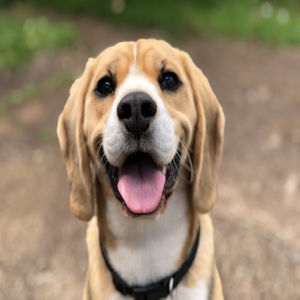

In [ ]:
# Cell 3: Fetch visual sample
import requests
from PIL import Image

# Download a sample image (e.g., a cute dog)
url = "https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=600"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Preprocess image for the vision transformer
image_input = preprocess(image).unsqueeze(0).to(device)

# Display input image in Colab
image.resize((300, 300))

### Cell 4: Encode Inputs into Shared Embedding Space
Passes the image through the Vision Encoder and candidate text prompts through the Text Encoder to extract normalized vector embeddings.

In [ ]:
# Cell 4: Extract visual and textual embeddings
# Define candidate text classes for zero-shot classification
candidate_texts = [
    "a photo of a happy dog",
    "a photo of a sleeping cat",
    "a picture of a sports car",
    "a futuristic robot in space"
]

# Tokenize text input
text_tokens = tokenizer(candidate_texts).to(device)

with torch.no_grad(), torch.cuda.amp.autocast():
    # 1. Encode image to vector representation
    image_features = model.encode_image(image_input)

    # 2. Encode text prompts to vector representations
    text_features = model.encode_text(text_tokens)

    # 3. L2 Normalize embeddings to compute cosine similarity via dot product
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

print(f"Image Embedding Shape: {image_features.shape}")
print(f"Text Embedding Shape:  {text_features.shape}")

/tmp/ipykernel_509/3010305035.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


Image Embedding Shape: torch.Size([1, 512])
Text Embedding Shape:  torch.Size([4, 512])


### Cell 5: Zero-Shot Classification & Cosine Similarity Matrix
Computes the dot product between normalized image and text embeddings to rank text candidates by visual similarity.

In [ ]:
# Cell 5: Compute Zero-Shot Similarity Scores
# Calculate cosine similarity (matrix multiplication of normalized features)
similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
probs = similarity.squeeze(0).cpu().numpy()

# Display predictions sorted by confidence
print("--- Zero-Shot Classification Results ---")
for text, prob in zip(candidate_texts, probs):
    print(f"Prompt: '{text:<30}' --> Confidence: {prob * 100:.2f}%")

--- Zero-Shot Classification Results ---
Prompt: 'a photo of a happy dog        ' --> Confidence: 100.00%
Prompt: 'a photo of a sleeping cat     ' --> Confidence: 0.00%
Prompt: 'a picture of a sports car     ' --> Confidence: 0.00%
Prompt: 'a futuristic robot in space   ' --> Confidence: 0.00%
